# Explore CDOM in Tara

In [33]:
# imports

from importlib import reload

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import numpy as np
from scipy import stats

from datetime import datetime, time
import random 

import pandas
import seaborn as sns

from oceancolor.tara import io as tara_io
from oceancolor.ph import pigments
from oceancolor.hydrolight import loisel23
from oceancolor.utils import cat_utils

from cnmf.oceanography import iops
from cnmf import zhu_nmf as nmf
from cnmf import io as cnmf_io

In [2]:
%matplotlib ipympl

# Load

## NMF

In [3]:
nmf_fit = 'Tara'
N_NMF, iop = 4, 'a'
d = cnmf_io.load_nmf(nmf_fit, N_NMF, iop)
M = d['M']
coeff = d['coeff']
NMF_wave = d['wave']

Loading: /home/xavier/Projects/Oceanography/python/cnmf/cnmf/data/Tara/Tara_NMF_04_a.npz


In [11]:
list(d.keys())

['M', 'coeff', 'spec', 'mask', 'err', 'wave', 'Rs', 'UID']

## Tara

In [4]:
tara = tara_io.load_pg_db(expedition='Microbiome')

Reading: /home/xavier/Projects/Oceanography/python/ocean-color/oceancolor/data/Tara/merged_tara_pacific_microbiome_acs_160124.feather


/home/xavier/Projects/Oceanography/python/ocean-color/oceancolor/tara/io.py:83: UserWarning: Duplicate times in Tara Oceans database
  warnings.warn("Duplicate times in Tara Oceans database")


Using bit_flags removes 127034 rows of a total 774298


In [5]:
tara

,dt,lat,lon,t,s,ad_model400,agaus406,agaus434,agaus453,agaus470,...,hbb_bbp_25,hbb_bbp_26,hbb_bbp_27,hbb_bbp_28,fdom_sd,fdom_sensor,geometry,uid,mission_id,passes_flags
utc_dt,,,,,,,,,,,,,,,,,,,,,
2020-12-26 19:39:00,26-Dec-2020 19:39:00,41.657277,-11.259457,14.559600,35.661383,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.077157,WSCD859,b'\x01\x01\x00\x00\x00\x8aO\xb8\x93\xd7\x84&\x...,1609011540000000000,1,True
2020-12-26 19:40:00,26-Dec-2020 19:40:00,41.655357,-11.260808,14.558767,35.661317,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.066062,WSCD859,b'\x01\x01\x00\x00\x0082\xd8\x98\x88\x85&\xc0%...,1609011600000000000,1,True
2020-12-26 19:41:00,26-Dec-2020 19:41:00,41.653373,-11.262016,14.555533,35.661383,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.055327,WSCD859,"b""\x01\x01\x00\x00\x00s\x96\x1a\x03'\x86&\xc0\...",1609011660000000000,1,True
2020-12-26 19:42:00,26-Dec-2020 19:42:00,41.651419,-11.263350,14.551517,35.661317,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.059899,WSCD859,b'\x01\x01\x00\x00\x00\xc7\xb5X\xc6\xd5\x86&\x...,1609011720000000000,1,True
2020-12-26 19:43:00,26-Dec-2020 19:43:00,41.649484,-11.264705,14.549850,35.661417,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.064867,WSCD859,b'\x01\x01\x00\x00\x00\xbcD>s\x87\x87&\xc0 \x1...,1609011780000000000,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-17 13:28:00,17-Sep-2022 13:28:00,14.689348,-17.384236,30.077350,34.853750,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.000956,SUVF6244,b'\x01\x01\x00\x00\x00\x17\xaa1E]b1\xc0\xa7\rG...,1663421280000000000,1,True
2022-09-17 13:29:00,17-Sep-2022 13:29:00,14.687992,-17.385693,30.091200,34.845950,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.000651,SUVF6244,b'\x01\x01\x00\x00\x00\xb7\xe2\xb1\xc3\xbcb1\x...,1663421340000000000,1,True
2022-09-17 13:30:00,17-Sep-2022 13:30:00,14.686636,-17.387150,30.095250,34.830933,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.001900,SUVF6244,b'\x01\x01\x00\x00\x00V\x1b2B\x1cc1\xc0q_\xfd\...,1663421400000000000,1,True


# CDOM 

In [6]:
NMF_CDOM = coeff[:,0]

In [29]:
tidx = cat_utils.match_ids(d['UID'], tara.uid, require_in_match=True)
tara_cdom = tara.fdom.values[tidx]

/home/xavier/Projects/Oceanography/python/ocean-color/oceancolor/utils/cat_utils.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  indices = xsorted[ypos]


## Distribution

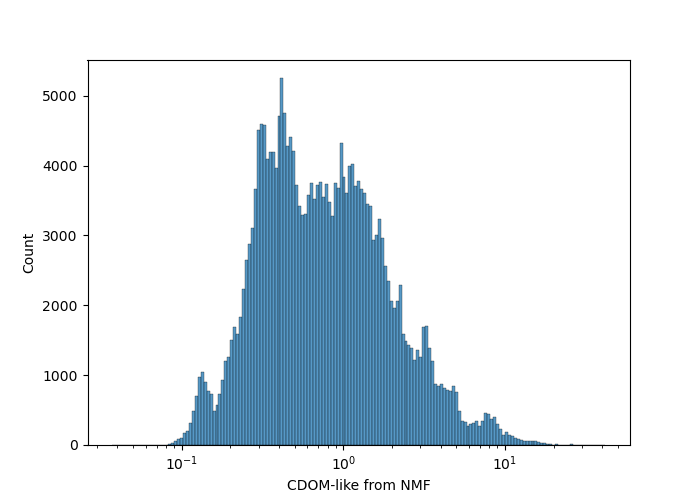

In [7]:
fig = plt.figure(figsize=(7,5))

plt.clf()
ax = plt.gca()
#
ax = sns.histplot(x=NMF_CDOM[NMF_CDOM > 1e-3], log_scale=True)
#
ax.set_xlabel('CDOM-like from NMF')
#
plt.show()

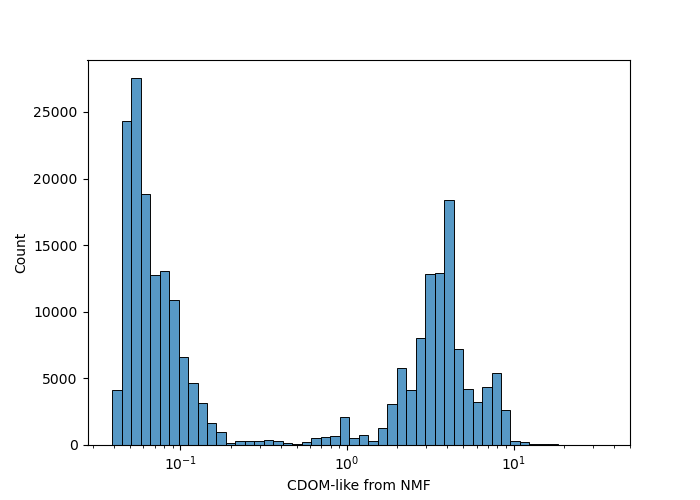

In [28]:
fig = plt.figure(figsize=(7,5))

plt.clf()
ax = plt.gca()
#
ax = sns.histplot(x=tara_cdom, log_scale=True)
#
ax.set_xlabel('CDOM-like from NMF')
#
plt.show()

# Compare H1 with FDOM

In [30]:
H1cut = NMF_CDOM > 1e-3
taracut = np.isfinite(tara_cdom) & (tara_cdom > 1e-4)
cut = H1cut & taracut

In [31]:
tara_cdom[cut].min()

0.0389118644067796

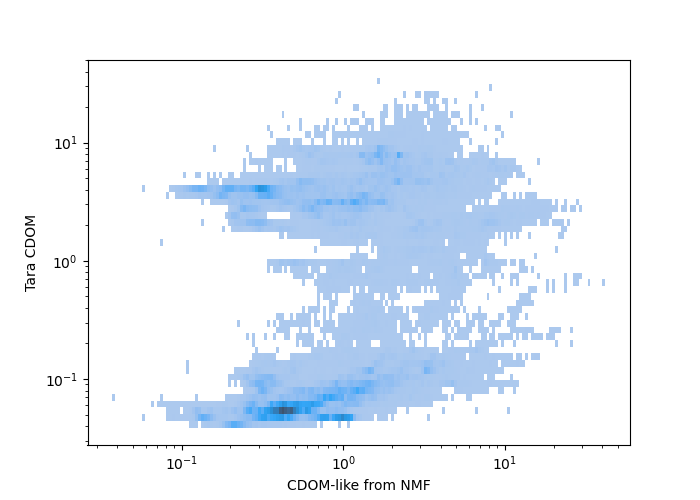

In [32]:
fig = plt.figure(figsize=(7,5))

plt.clf()
ax = plt.gca()
#
ax = sns.histplot(x=NMF_CDOM[cut], y=tara_cdom[cut], log_scale=True)
#
ax.set_xlabel('CDOM-like from NMF')
ax.set_ylabel('Tara CDOM')
#ax.set_ylabel(r'CDOM from $a_g$')
#ax.legend()
#
plt.show()

# Stats

In [34]:
tau, p_value = stats.kendalltau(NMF_CDOM[cut], tara_cdom[cut])
tau, p_value

(0.22938069903800803, 0.0)